## Ovrlpy can help identify spurious spatial cell types

In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import ovrlpy
import pandas as pd
import polars as pl
from matplotlib.patches import Rectangle
from matplotlib_scalebar.scalebar import ScaleBar

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys

import matplotlib

sys.path.append("..")


from ovrlpy._plotting import BIH_CMAP, _plot_signal_integrity

from utils import CM, FONT, save_kwargs

matplotlib.rc("font", **FONT)

In [3]:
fig_dir = Path("fig")

data_folder = Path("data")
sc_data_path = data_folder / "GSE113576"

In [4]:
fig_dir.mkdir(exist_ok=True)

### data

#### Transcripts in the Tissue Section

In [5]:
columns = {"Centroid_X": "x", "Centroid_Y": "y", "Centroid_Z": "z", "Gene_name": "gene"}

signal_coordinate_df = pd.read_csv(
    data_folder / "merfish_barcodes_example.csv",
    usecols=columns.keys(),
    dtype={"Gene_name": "category"},
).rename(columns=columns)

signal_coordinate_df = signal_coordinate_df.loc[
    ~signal_coordinate_df["gene"].str.contains("Blank|NegControl")
]

coordinate_x_m = signal_coordinate_df["x"].min()
coordinate_y_m = signal_coordinate_df["y"].min()
signal_coordinate_df["x"] = signal_coordinate_df["x"] - coordinate_x_m
signal_coordinate_df["y"] = signal_coordinate_df["y"] - coordinate_y_m

#### Results of BANKSY

In [6]:
columns = {
    "Centroid_X": "x",
    "Centroid_Y": "y",
    "Bregma": "Bregma",
    "lam0.2": "banksy_cluster",
}

banksy_result = pd.read_csv(
    data_folder / "banksy_cluster.txt", usecols=columns.keys(), sep="\t"
).rename(columns=columns)

banksy_result = banksy_result[banksy_result["Bregma"] == -0.24]

banksy_result["x"] = banksy_result["x"] - coordinate_x_m
banksy_result["y"] = banksy_result["y"] - coordinate_y_m

In [7]:
MOD1_df = banksy_result[banksy_result["banksy_cluster"] == 8]
MOD2_df = banksy_result[banksy_result["banksy_cluster"] == 7]

differentially expressed genes identified by BANKSY

In [8]:
# DE_genes_MOD2: 7
DE_genes_MOD2 = [
    "Mlc1",
    "Dgkk",
    "Cbln2",
    "Syt4",
    "Gad1",
    "Plin3",
    "Gnrh1",
    "Sln",
    "Gjc3",
]
# DE_genes_MOD1: 8
DE_genes_MOD1 = ["Mbp", "Lpar1", "Trh", "Ucn3", "Cck"]

In [9]:
MOD1_signals = signal_coordinate_df[
    signal_coordinate_df["gene"].isin(DE_genes_MOD1)
].copy()
MOD2_signals = signal_coordinate_df[
    signal_coordinate_df["gene"].isin(DE_genes_MOD2)
].copy()

#### Segmentation Dataset

In [10]:
merfish_data = pd.read_csv(
    data_folder / "Moffitt_and_Bambah-Mukku_et_al_merfish_all_cells.csv"
).rename(columns={"Centroid_X": "x", "Centroid_Y": "y"})

merfish_data = merfish_data.drop(
    columns=[
        col for col in merfish_data.columns if col == "Fos" or col.startswith("Blank_")
    ]
)
merfish_data = merfish_data[merfish_data["Cell_class"] != "Ambiguous"]
merfish_data = merfish_data[merfish_data["Animal_ID"] == 1]
merfish_data = merfish_data[merfish_data["Bregma"] == -0.24]

merfish_data["x"] -= coordinate_x_m
merfish_data["y"] -= coordinate_y_m

merfish_data = merfish_data.merge(
    banksy_result[["x", "y", "banksy_cluster"]], on=["x", "y"], how="left"
)
merfish_data = merfish_data.rename(columns={"banksy_cluster": "banksy"})

cell_class_m = {
    "Astrocyte": "Astrocyte",
    "Endothelial 1": "Endothelial",
    "Endothelial 2": "Endothelial",
    "Endothelial 3": "Endothelial",
    "Ependymal": "Ependymal",
    "Excitatory": "Excitatory",
    "Inhibitory": "Inhibitory",
    "Microglia": "Microglia",
    "OD Immature 1": "OD Immature",
    "OD Immature 2": "OD Immature",
    "OD Mature 1": "OD Mature",
    "OD Mature 2": "OD Mature",
    "OD Mature 3": "OD Mature",
    "OD Mature 4": "OD Mature",
    "Pericytes": "Pericytes",
}

merfish_data["Cell_class"] = (
    merfish_data["Cell_class"].map(cell_class_m).fillna("Other")
)

merfish_data = merfish_data.sort_values(by="Cell_class")

#### Cell boundaries

In [11]:
boundaries_df = pd.read_csv(data_folder / "cellboundaries_example_animal.csv")
boundaries_df = boundaries_df.dropna(subset=["boundaryX", "boundaryY"])

cell_ids = merfish_data["Cell_ID"]
boundaries_df = boundaries_df[boundaries_df["feature_uID"].isin(cell_ids)]
boundaries_df = boundaries_df.merge(
    merfish_data[["Cell_ID", "x", "y", "banksy", "Cell_class"]],
    left_on="feature_uID",
    right_on="Cell_ID",
    how="inner",
).drop(columns=["Cell_ID"])

boundaries_df["boundaryX"] = boundaries_df["boundaryX"].apply(
    lambda x: [float(i) for i in x.split(";")] if isinstance(x, str) else x
)
boundaries_df["boundaryY"] = boundaries_df["boundaryY"].apply(
    lambda x: [float(i) for i in x.split(";")] if isinstance(x, str) else x
)

boundaries_df["boundaryX"] = boundaries_df["boundaryX"].apply(
    lambda x: [i - coordinate_x_m for i in x] if isinstance(x, list) else x
)
boundaries_df["boundaryY"] = boundaries_df["boundaryY"].apply(
    lambda x: [i - coordinate_y_m for i in x] if isinstance(x, list) else x
)

In [12]:
MOD1_boundaries = boundaries_df[boundaries_df["banksy"] == 8].copy()
MOD2_boundaries = boundaries_df[boundaries_df["banksy"] == 7].copy()

#### Matched Single-Cell RNA Sequencing

In [13]:
from pandas.api.types import CategoricalDtype
from scipy import sparse
from scipy.io import mmread


def load_scRNA_data(mtx_path, barcodes_path, genes_path, meta_path, cell_class_filter):
    adata = ad.AnnData(
        X=sparse.csc_array(mmread(mtx_path)).T,
        obs=pd.read_table(barcodes_path, index_col=0, names=["barcode"]),
        var=pd.read_table(genes_path, index_col=0, names=["id", "symbol"]),
    )

    meta = (
        pd.read_excel(meta_path, skiprows=1)
        .rename(
            columns={
                "Cell name": "Cell_name",
                "Sex": "Sex",
                "Replicate number": "Rep",
                "Cell class (determined from clustering of all cells)": "Cell_class",
                "Non-neuronal cluster (determined from clustering of all cells)": "Non_neuronal_cluster",
                "Neuronal cluster (determined from clustering of inhibitory or excitatory neurons)": "Neuronal_cluster",
            }
        )
        .set_index("Cell_name")
    )
    meta = meta.loc[meta["Cell_class"].isin(cell_class_filter.keys())]
    adata = adata[adata.obs_names.isin(meta.index)].copy()
    adata.obs = meta.loc[adata.obs_names, ["Cell_class"]].copy()
    adata.obs["Cell_class"] = adata.obs["Cell_class"].map(cell_class_filter)

    cell_class_order = list(cell_class_filter.values())
    cat_dtype = CategoricalDtype(categories=cell_class_order, ordered=True)
    adata.obs["Cell_class"] = adata.obs["Cell_class"].astype(cat_dtype)

    mt_mask = adata.var["symbol"].str.startswith("mt")
    mt_fraction = adata[:, mt_mask].X.sum(axis=1) / adata.X.sum(axis=1)
    adata = adata[mt_fraction < 0.2, :].copy()

    nonzero_counts = (adata.X != 0).sum(axis=1)
    adata = adata[nonzero_counts > 1_000, :].copy()

    normalizer = sparse.diags(10_000 / adata.X.sum(axis=1))
    adata.X = normalizer.dot(adata.X)

    adata.X = adata.X.log1p()

    return adata

In [14]:
cell_class_dict = {
    "Astrocytes": "Astrocytes",
    "Microglia": "Microglia",
    "Macrophage": "Macrophage",
    "Excitatory": "Excitatory",
    "Inhibitory": "Inhibitory",
    "Immature oligodendrocyte": "OD immature",
    "Newly formed oligodendrocyte": "OD newly formed",
    "Mature oligodendrocyte": "OD mature",
    "Ependymal": "Ependymal",
    "Endothelial": "Endothelial",
    "Mural": "Mural",
    "Fibroblast": "Fibroblast",
}

adata = load_scRNA_data(
    mtx_path=sc_data_path / "GSE113576_matrix.mtx.gz",
    barcodes_path=sc_data_path / "GSE113576_barcodes.tsv.gz",
    genes_path=sc_data_path / "GSE113576_genes.tsv.gz",
    meta_path=data_folder / "aau5324_moffitt_table-s1.xlsx",
    cell_class_filter=cell_class_dict,
)

In [15]:
adata = adata[adata.obs.sort_values("Cell_class").index]
adata.var = adata.var.set_index("symbol")

sc_data = adata.to_df()
sc_DE_MOD1_df = sc_data[DE_genes_MOD1]
sc_DE_MOD2_df = sc_data[DE_genes_MOD2]
sc_DE = pd.concat([sc_DE_MOD1_df, sc_DE_MOD2_df], axis=1)

sc_cell_class = adata.obs["Cell_class"]

### Ovrlpy pipeline

In [16]:
dataset = ovrlpy.Ovrlp(
    signal_coordinate_df, n_components=15, n_workers=8, random_state=42
)

dataset.analyse()

Running vertical adjustment
Creating gene expression embeddings for visualization
determining pseudocells
found 3915 pseudocells
sampling expression:


100%|██████████| 4/4 [00:01<00:00,  2.72it/s]


Modeling 15 pseudo-celltype clusters;
Creating signal integrity map


100%|██████████| 16/16 [00:10<00:00,  1.59it/s]


In [17]:
signal_integrity = dataset.integrity_map
signal_strength = dataset.signal_map
pseudocells = dataset.pseudocells

doublets = dataset.detect_doublets(min_signal=3, integrity_sigma=1)

### cell type map
Cell types are colored according to the original publication ([Moffitt et al., 2018](https://www.science.org/doi/10.1126/science.aau5324)).

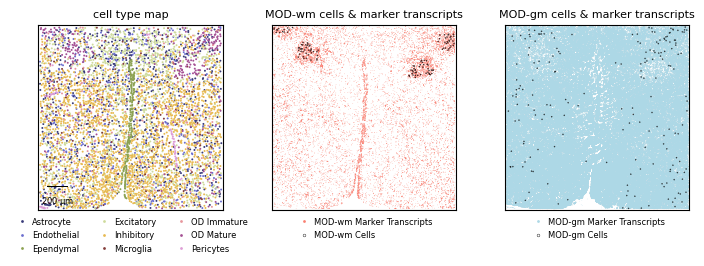

In [18]:
all_labels = sorted(merfish_data["Cell_class"].unique())
colormap = plt.get_cmap("tab20b", len(all_labels))
label_to_color = {label: colormap(i) for i, label in enumerate(all_labels)}
colors = merfish_data["Cell_class"].map(label_to_color)

legend_kwargs = dict(
    handletextpad=0.2, loc="upper center", frameon=False, bbox_to_anchor=(0.5, 0)
)

fig, axs = plt.subplots(ncols=3, figsize=(18 * CM, 9 * CM), sharex=True, sharey=True)


for ax in axs:
    ax.set(xticks=[], yticks=[], aspect="equal")

# celltype map
axs[0].scatter(
    merfish_data["x"],
    merfish_data["y"],
    s=2,
    c=colors,
    edgecolors="none",
    rasterized=True,
)

axs[0].set(xlim=(-10, 1810), ylim=(-10, 1810))
axs[0].set_title("cell type map", fontsize=8)

handles = [
    mlines.Line2D(
        [0],
        [0],
        marker=".",
        linestyle="None",
        color="none",
        markerfacecolor=label_to_color[label],
        markeredgecolor="none",
        markersize=4,
        label=label,
    )
    for label in all_labels
]

axs[0].legend(handles=handles, ncol=3, **legend_kwargs)

# MOD-wm
marker_scatter = dict(s=0.15, edgecolors="none", rasterized=True)
cell_scatter = dict(
    s=0.5, facecolors="none", edgecolors="#080808", linewidths=0.3, rasterized=True
)

axs[1].scatter(MOD1_signals["x"], MOD1_signals["y"], c="salmon", **marker_scatter)
axs[1].scatter(MOD1_df["x"], MOD1_df["y"], **cell_scatter)

label_to_color = {"MOD-wm Marker Transcripts": "salmon", "MOD-wm Cells": "#080808"}
handles = [
    mlines.Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=color if "Marker" in label else "none",
        markeredgecolor=color,
        linestyle="None",
        markersize=2,
        markeredgewidth=0.3 if "Marker" not in label else 0,
        label=label,
    )
    for label, color in label_to_color.items()
]
axs[1].legend(handles=handles, **legend_kwargs)

axs[1].set_title("MOD-wm cells & marker transcripts", fontsize=8)

# MOD-gm
axs[2].scatter(MOD2_signals["x"], MOD2_signals["y"], c="lightblue", **marker_scatter)
axs[2].scatter(MOD2_df["x"], MOD2_df["y"], **cell_scatter)

label_to_color = {"MOD-gm Marker Transcripts": "lightblue", "MOD-gm Cells": "#080808"}
handles = [
    mlines.Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=color if "Marker" in label else "none",
        markeredgecolor=color,
        linestyle="None",
        markersize=2,
        markeredgewidth=0.3 if "Marker" not in label else 0,
        label=label,
    )
    for label, color in label_to_color.items()
]
axs[2].legend(handles=handles, **legend_kwargs)

axs[2].set_title("MOD-gm cells & marker transcripts", fontsize=8)

axs[0].add_artist(ScaleBar(1, units="um", frameon=False, loc="lower left"))


fig.tight_layout()
fig.savefig(fig_dir / "CellTypes_markers.svg", **save_kwargs)

### VSI distribution within MOD subtypes
VSI values of pixels within MOD1 and MOD2 cell boundaries.

In [19]:
from matplotlib.path import Path as mPath
from shapely.geometry import Polygon


def extract_cell_vsi(boundary_df, integrity, strength, integrity_size=1800):
    """
    Extracts the cell integrity and strength arrays based on polygonal boundaries.
    """

    cell_integrity = np.zeros((integrity_size, integrity_size))
    cell_strength = np.zeros((integrity_size, integrity_size))

    for idx, row in boundary_df.iterrows():
        x_coords = np.array(row["boundaryX"])
        y_coords = np.array(row["boundaryY"])

        valid_mask = ~np.isnan(x_coords) & ~np.isnan(y_coords)
        x_coords = x_coords[valid_mask]
        y_coords = y_coords[valid_mask]

        if len(x_coords) < 3:
            continue

        polygon = Polygon(zip(x_coords, y_coords))
        if not polygon.is_valid:
            continue

        x_min, x_max = int(np.floor(polygon.bounds[0])), int(np.ceil(polygon.bounds[2]))
        y_min, y_max = int(np.floor(polygon.bounds[1])), int(np.ceil(polygon.bounds[3]))

        x_min, x_max = max(0, x_min), min(integrity_size, x_max)
        y_min, y_max = max(0, y_min), min(integrity_size, y_max)

        y_indices, x_indices = np.meshgrid(
            range(y_min, y_max), range(x_min, x_max), indexing="ij"
        )
        points = np.column_stack([x_indices.ravel(), y_indices.ravel()])

        path = mPath(np.column_stack((x_coords, y_coords)))
        epsilon = 0.5
        mask = path.contains_points(points, radius=epsilon)
        mask = mask.reshape(y_indices.shape)

        subgrid_int = integrity[y_min:y_max, x_min:x_max]
        subgrid_str = strength[y_min:y_max, x_min:x_max]

        cell_integrity[y_min:y_max, x_min:x_max] = np.where(
            mask, subgrid_int, cell_integrity[y_min:y_max, x_min:x_max]
        )
        cell_strength[y_min:y_max, x_min:x_max] = np.where(
            mask, subgrid_str, cell_strength[y_min:y_max, x_min:x_max]
        )

    return cell_integrity, cell_strength

In [20]:
MOD1_int, MOD1_str = extract_cell_vsi(
    MOD1_boundaries, signal_integrity, signal_strength
)
MOD2_int, MOD2_str = extract_cell_vsi(
    MOD2_boundaries, signal_integrity, signal_strength
)

In [21]:
def plot_histogram(
    ax,
    cell_integrity,
    cell_strength,
    signal_threshold,
    cmap,
    label,
    ylim=(1e-1, 32),
    title=None,
):
    n, bins, patches = ax.hist(
        cell_integrity[cell_strength > signal_threshold],
        bins=50,
        range=(0, 1),
        density=True,
        edgecolor="black",
        linewidth=0.5,
    )

    for i, patch in enumerate(patches):
        patch.set_facecolor(cmap(i / len(patches)))

    ax.set(xlim=(0, 1), ylim=ylim, yscale="log", ylabel="Density", xlabel=label)
    ax.set_title(title, fontsize=8)

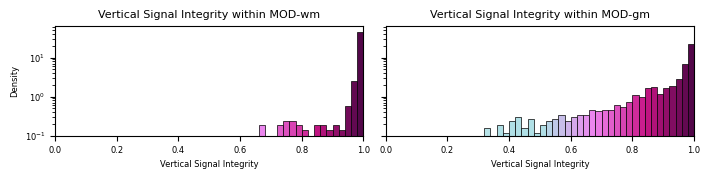

In [22]:
fig, axs = plt.subplots(ncols=2, figsize=(18 * CM, 4.5 * CM), sharex=True)

plot_histogram(
    axs[0],
    cell_integrity=MOD1_int,
    cell_strength=MOD1_str,
    signal_threshold=3,
    cmap=BIH_CMAP,
    label="Vertical Signal Integrity",
    ylim=(1e-1, 64),
    title="Vertical Signal Integrity within MOD-wm",
)

plot_histogram(
    axs[1],
    cell_integrity=MOD2_int,
    cell_strength=MOD2_str,
    signal_threshold=3,
    cmap=BIH_CMAP,
    label="Vertical Signal Integrity",
    ylim=(1e-1, 64),
    title="Vertical Signal Integrity within MOD-gm",
)
axs[1].set(ylabel=None)
axs[1].set_yticklabels([])

fig.tight_layout()
fig.savefig(fig_dir / "VSI_hist.svg", **save_kwargs)

### Marker expression in non-oligodendrocyte cells (scRNA-seq)

In [23]:
noOD_sc_data = pd.concat([sc_DE, sc_cell_class], axis=1)
noOD_sc_data = noOD_sc_data[~noOD_sc_data["Cell_class"].str.startswith("OD")]

noOD_sc_cell_class = noOD_sc_data["Cell_class"]
noOD_sc_data = noOD_sc_data.drop("Cell_class", axis=1)

Gene_Group = pd.DataFrame(
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1], columns=["cluster"]
)

In [24]:
import seaborn as sns
from scipy.cluster.hierarchy import leaves_list, linkage

HEATMAP_CMAP = sns.color_palette("RdYlBu_r", as_cmap=True)

In [25]:
def plot_annotate_heatmap(
    cluster_data,
    cluster_labels,
    gene_groups=None,
    zscore=True,
    cmap=HEATMAP_CMAP,
    cluster_text_y=-1.2,
    show_cluster=True,
    show_cluster_lines=True,
    DE_g_line=True,
):
    cluster_data = cluster_data.copy()
    cluster_data["Cell_class"] = cluster_labels

    cluster_data = cluster_data.sort_values(by="Cell_class")
    cell_class_col = cluster_data["Cell_class"]

    numeric_data = cluster_data.drop(columns=["Cell_class"]).apply(
        pd.to_numeric, errors="coerce"
    )
    numeric_data = numeric_data.dropna(axis=1).loc[:, ~numeric_data.T.duplicated()]

    cluster_data = pd.concat([cell_class_col, numeric_data], axis=1)
    expression_data = cluster_data.drop("Cell_class", axis=1)
    expression_data = expression_data.loc[:, ~expression_data.columns.duplicated()]

    cluster_labels_sorted = cluster_data["Cell_class"].values
    unique_labels = pd.Series(cluster_labels_sorted).unique()

    expression_data = expression_data.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
    vmin, vmax = -3, 3

    new_order = []
    for label in unique_labels:
        indices = np.where(cluster_labels_sorted == label)[0]
        subset = expression_data.iloc[indices, :]
        if subset.shape[0] > 1:
            linkage_matrix = linkage(subset, method="ward")
            sorted_indices = indices[leaves_list(linkage_matrix)]
        else:
            sorted_indices = indices
        new_order.extend(sorted_indices)

    reordered_expression_data = expression_data.iloc[new_order, :]
    reordered_cluster_labels = cluster_labels_sorted[new_order]

    if gene_groups is not None:
        new_gene_order = []
        for label in sorted(set(gene_groups["cluster"])):
            gene_indices = np.where(gene_groups == label)[0]
            subset = reordered_expression_data.iloc[:, gene_indices]
            if subset.shape[1] > 1:
                linkage_matrix = linkage(subset.T, method="average")
                sorted_gene_indices = gene_indices[leaves_list(linkage_matrix)]
            else:
                sorted_gene_indices = gene_indices
            new_gene_order.extend(sorted_gene_indices)
    else:
        new_gene_order = leaves_list(
            linkage(reordered_expression_data.T, method="average")
        )

    reordered_expression_data = reordered_expression_data.iloc[:, new_gene_order]

    fig, ax = plt.subplots(figsize=(6 * CM, 8 * CM))
    _ = sns.heatmap(
        reordered_expression_data,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        xticklabels=True,
        yticklabels=False,
        cbar=True,
        ax=ax,
        cbar_kws={"shrink": 0.5},
        rasterized=True,
    )

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set(ylabel=None, xlabel=None)

    cluster_boundaries = []
    for label in unique_labels:
        indices = np.where(reordered_cluster_labels == label)[0]
        if len(indices) == 0:
            continue
        start, end = indices[0], indices[-1]
        y_pos = (start + end) / 2
        if show_cluster:
            ax.text(
                cluster_text_y, y_pos, str(label), ha="center", va="center", rotation=0
            )
        cluster_boundaries.append(end)

    if show_cluster_lines:
        for boundary in cluster_boundaries[:-1]:
            ax.axhline(y=boundary, color="black", linestyle="--", lw=0.5)

    if DE_g_line:
        ax.vlines(
            x=5,
            ymin=ax.get_ylim()[0],
            ymax=ax.get_ylim()[1],
            color="black",
            linestyle="--",
            linewidth=0.5,
        )

    ax.set_title("MOD-gm/wm marker expression in scRNAseq", fontsize=8)

    for ax in fig.axes:
        for spine in ax.spines.values():
            spine.set_edgecolor("black")
            spine.set_linewidth(1)
            spine.set_visible(True)

    fig.savefig(fig_dir / "heatmap.svg", **save_kwargs)

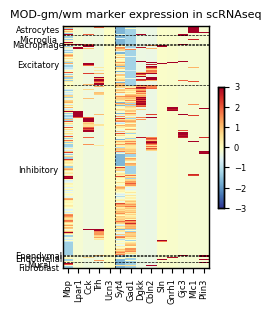

In [26]:
plot_annotate_heatmap(
    cluster_data=noOD_sc_data,
    cluster_labels=noOD_sc_cell_class,
    gene_groups=Gene_Group,
    cluster_text_y=-2.3,
)

### Overlapping ROIs
Examples of MOD2 cells spatially overlapping with annotated excitatory and inhibitory neurons  

In [27]:
windowsize = 60
window_size = windowsize / 2

signal_threshold = 3.0
roi_scatter_kwargs = dict(
    marker=".", alpha=0.8, s=5, edgecolors="none", rasterized=True
)

embedding = pseudocells.obsm["2D_UMAP"]
RGB = pseudocells.obsm["RGB"]
spatial = pseudocells.obsm["spatial"]

In [28]:
def plot_doublet(axs, i, window_size=30):
    x, y = doublets["x", "y"].row(i)
    roi = ((x - window_size, x + window_size), (y - window_size, y + window_size))

    ROI_in = dataset.transcripts.filter(
        pl.col("x").is_between(x - window_size, x + window_size)
        & pl.col("y").is_between(y - window_size, y + window_size)
    ).sort("z")

    _, embedding_color = dataset.transform_transcripts(ROI_in)
    ROI_in = ROI_in.with_columns(RGB=embedding_color)

    for ax in axs:
        ax.set(xlim=roi[0], ylim=roi[1])

    # VSI map
    ax_vsi = axs[0]
    ax_vsi.set_facecolor("black")
    ax_vsi.set_title("VSI", fontsize=6)
    img = _plot_signal_integrity(
        ax_vsi, signal_integrity, signal_strength, signal_threshold
    )

    _ = fig.colorbar(img, cax=axs[1])

    # TOP
    roi_top = ROI_in.filter(pl.col("z") > pl.col("z_center"))

    ax_top = axs[2]
    ax_top.scatter(
        roi_top["x"], roi_top["y"], c=roi_top["RGB"].to_numpy(), **roi_scatter_kwargs
    )
    ax_top.set_title("top", fontsize=6)

    # bottom
    roi_bottom = ROI_in.filter(pl.col("z") < pl.col("z_center")).reverse()

    ax_bottom = axs[3]
    ax_bottom.scatter(
        roi_bottom["x"],
        roi_bottom["y"],
        c=roi_bottom["RGB"].to_numpy(),
        **roi_scatter_kwargs,
    )
    ax_bottom.set_title("bottom", fontsize=6)

    # cell outlines
    filtered_df = boundaries_df[
        (boundaries_df["x"] >= roi[0][0])
        & (boundaries_df["x"] <= roi[0][1])
        & (boundaries_df["y"] >= roi[1][0])
        & (boundaries_df["y"] <= roi[1][1])
    ]

    for ax in [ax_top, ax_bottom]:
        for _, row in filtered_df.iterrows():
            ax.plot(row["boundaryX"], row["boundaryY"], c="#2C2C2C", linewidth=0.7)

In [29]:
rois = [158, 49]

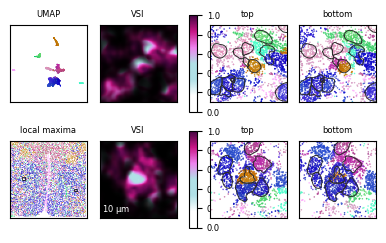

In [30]:
fig, axs = plt.subplots(
    nrows=2, ncols=5, figsize=(12 * CM, 7 * CM), width_ratios=[1, 1, 0.1, 1, 1]
)

ax_umap = axs[0, 0]
ax_umap.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=RGB,
    alpha=0.5,
    marker=".",
    edgecolors="none",
    s=2,
    rasterized=True,
)
ax_umap.set(adjustable="box", xlim=(-9, 24), ylim=(-12, 21))
ax_umap.set_title("UMAP", fontsize=6)


ax_ct = axs[1, 0]
ax_ct.scatter(
    spatial[:, 0],
    spatial[:, 1],
    c=RGB,
    marker=".",
    edgecolors="none",
    s=2,
    rasterized=True,
)

patch_kwargs = dict(
    width=windowsize, height=windowsize, linewidth=0.5, fill=False, edgecolor="k"
)

x_center, y_center = doublets["x", "y"].row(rois[0])
square = Rectangle((x_center - window_size, y_center - window_size), **patch_kwargs)
ax_ct.add_patch(square)

x_center, y_center = doublets["x", "y"].row(rois[1])
square = Rectangle((x_center - window_size, y_center - window_size), **patch_kwargs)
ax_ct.add_patch(square)

ax_ct.set(xlim=(-30, 1830), ylim=(-30, 1830))
ax_ct.set_title("local maxima", fontsize=6)

plot_doublet(axs[0, 1:], rois[0])
plot_doublet(axs[1, 1:], rois[1])

axs[1, 1].add_artist(
    ScaleBar(1, units="um", frameon=False, loc="lower left", color="w")
)


for ax in axs[:, [0, 1, 3, 4]].ravel():
    ax.set(xticks=[], yticks=[], aspect="equal")

# fig.tight_layout()
fig.savefig(fig_dir / "doublets.svg", **save_kwargs)

In [62]:
signatures = (
    merfish_data.drop(
        columns=[
            "Cell_ID",
            "Animal_ID",
            "Animal_sex",
            "Behavior",
            "Bregma",
            "x",
            "y",
            "Neuron_cluster_ID",
            "banksy",
        ]
    )
    .groupby("Cell_class")
    .agg("mean")
)

dataset.fit_signatures(
    signatures[[c for c in signatures.columns if c in dataset.genes]]
)

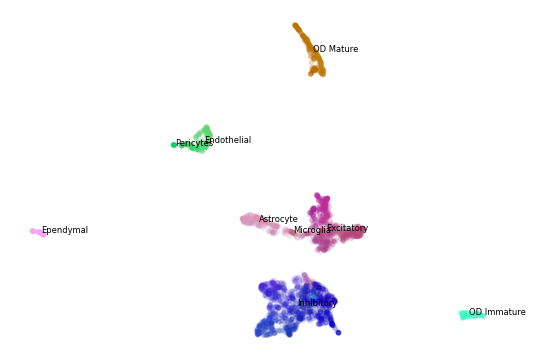

In [63]:
ovrlpy.plot_umap(dataset)